# **Heavy Equipment Selling Price Prediction**

## Machine Learning Practice Project

The objective of this project is to build a regression model that predicts the selling price of heavy equipment using the available machine and transaction-related features.

The notebook follows a complete machine learning workflow including:

- Data loading and initial inspection
- Exploratory Data Analysis (EDA)
- Data preprocessing and missing value handling
- Feature engineering
- Model training and validation
- Baseline model comparison
- Hyperparameter tuning
- Ensemble modelling
- Final prediction and submission generation

The primary evaluation metric used is **Root Mean Squared Logarithmic Error (RMSLE)**.

## 1. Importing Libraries

The required libraries are imported for data manipulation, visualization, preprocessing, model training, and evaluation.

- **NumPy and Pandas** are used for numerical operations and data manipulation.
- **Matplotlib and Seaborn** are used for exploratory data visualization.
- **Scikit-learn** utilities are used for preprocessing, validation, and evaluation.
- **CatBoost, XGBoost, and LightGBM** are used as gradient boosting regression models.


In [1]:
import numpy as np 
import pandas as pd 

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.metrics import mean_squared_log_error
from catboost import CatBoostRegressor
import xgboost as xgb
import lightgbm as lgb
pd.set_option("display.max_columns", 100)

/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv


## 2. Data Loading

The training and test datasets are loaded using Pandas.

The **training dataset** contains the target variable along with the input features and is used for model development.

The **test dataset** contains the corresponding input features without the target variable and is used to generate the final predictions for submission.

In [2]:
train = pd.read_csv(
    "/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv"
)

test = pd.read_csv(
    "/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv"
)

submission = pd.read_csv(
    "/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv"
)

/tmp/ipykernel_16/1619439496.py:1: DtypeWarning: Columns (38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv(


### 2.1 Dataset Overview

Before preprocessing, the datasets are inspected to understand their dimensions, columns, data types, and sample observations.

This initial inspection helps identify:

- The number of observations and features
- Numerical and categorical variables
- Missing values
- Potential preprocessing requirements
- The structure of the target and predictor variables

## 3. Exploratory Data Analysis

Exploratory Data Analysis is performed to understand the target distribution, identify missing values and anomalous observations, examine relationships between numerical features and the target, and study the categorical features before feature engineering and model training.

### 3.1 Target Variable Analysis

`TargetValue` is the continuous variable to be predicted. Its descriptive statistics and skewness are examined to understand the range and distribution of selling prices.

A strongly skewed target can cause large selling prices to have a disproportionate influence on model training and evaluation.

In [3]:
# Target variable distribution

print(train["TargetValue"].describe())
print("\nSkewness:", train["TargetValue"].skew())

count    138701.000000
mean      41521.874047
std       26361.125948
min        7500.000000
25%       20500.000000
50%       35000.000000
75%       57000.000000
max      142000.000000
Name: TargetValue, dtype: float64

Skewness: 0.9699963984208283


#### Target Distribution and Log Transformation

The distribution of `TargetValue` is compared with its logarithmically transformed version using `log1p`.

The original selling-price distribution is right-skewed, while the logarithmic transformation produces a more balanced distribution. This is particularly relevant because the project is evaluated using RMSLE, which measures prediction error on a logarithmic scale.

Therefore, the target is later modelled in log space and predictions are transformed back to the original price scale when required.

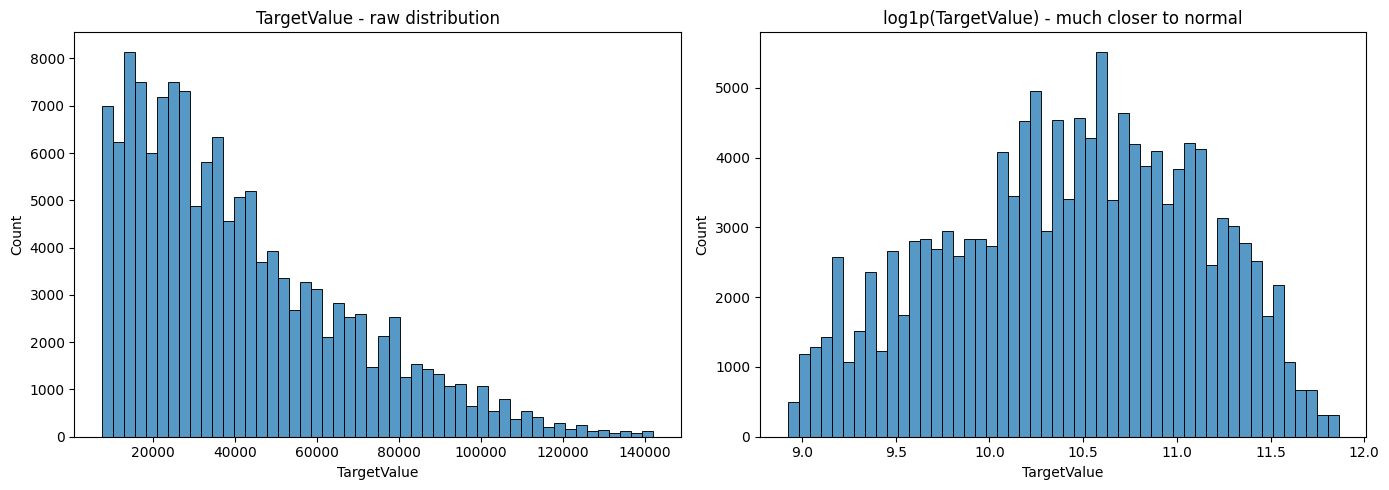

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(train["TargetValue"], bins=50, ax=axes[0])
axes[0].set_title("TargetValue - raw distribution")

sns.histplot(np.log1p(train["TargetValue"]), bins=50, ax=axes[1])
axes[1].set_title("log1p(TargetValue) - much closer to normal")
plt.tight_layout()
plt.show()

### 3.2 Missing Value Analysis

The percentage of missing values is calculated for each feature to identify variables with incomplete observations.

The features with the highest missing-value percentages are visualized to understand the extent of missingness in the dataset. Since several useful equipment attributes contain missing values, these features are not immediately discarded. Missing values are handled later during preprocessing according to the feature type and model requirements.

col19                 99.952416
col18                 99.952416
col5                  92.515555
col4                  92.515555
col27                 89.214930
col28                 89.214930
col29                 86.393753
col30                 86.393753
col13                 83.125572
col14                 83.125572
col7                  83.125572
col6                  83.125572
col9                  83.125572
col8                  83.125572
col11                 83.125572
col3                  78.909309
Forks                 78.861724
Spec_ReleaseSeries    76.282795
col1                  75.641127
col12                 72.340502
dtype: float64


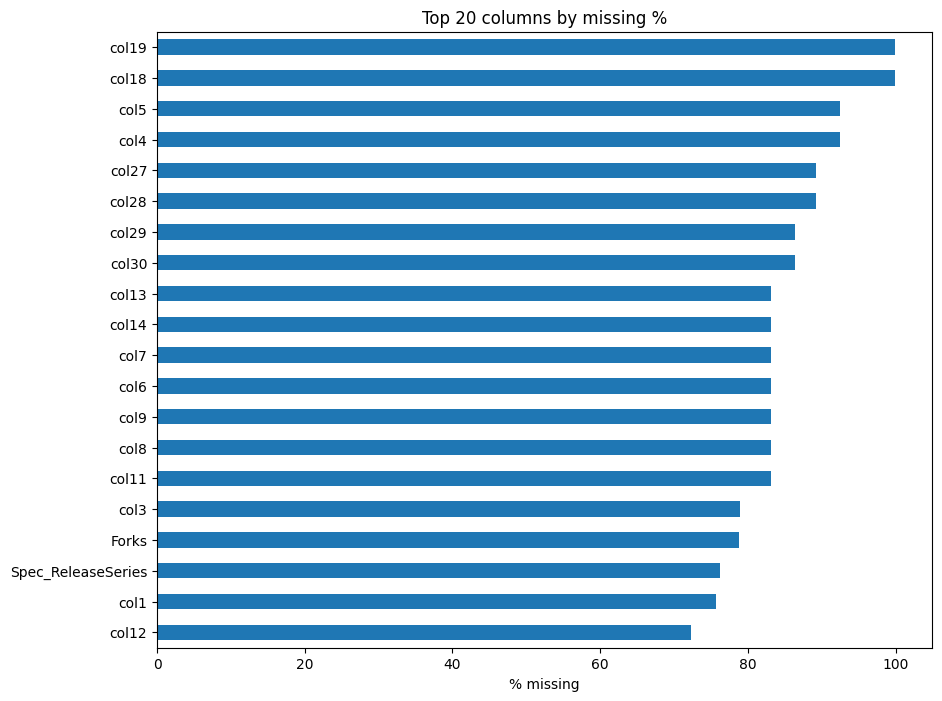

In [5]:
# Missing values overview

missing_pct = (train.isna().mean() * 100).sort_values(ascending=False)
print(missing_pct.head(20))

plt.figure(figsize=(10, 8))
missing_pct.head(20).plot(kind="barh")
plt.xlabel("% missing")
plt.title("Top 20 columns by missing %")
plt.gca().invert_yaxis()
plt.show()

### 3.3 Manufacture Year Investigation

`ManufactureYear` is examined separately because the manufacturing year is useful for estimating the age of a machine, which can influence its selling price.

The distribution is inspected for unrealistic values, particularly years below 1900. These observations are treated as anomalous rather than valid manufacturing years and are handled during feature engineering before machine age is calculated.

count    138701.000000
mean       1891.640853
std         306.992001
min        1001.000000
25%        1990.000000
50%        1998.000000
75%        2004.000000
max        2015.000000
Name: ManufactureYear, dtype: float64

rows with ManufactureYear < 1900: 14719


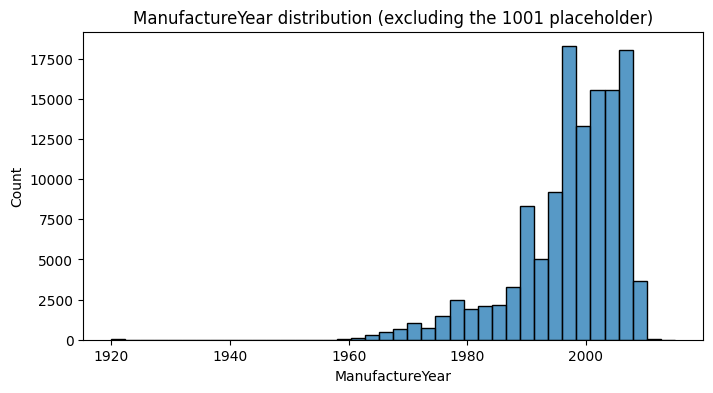

In [6]:
# ManufactureYear anomaly check
# this is the "1001 = unknown year" placeholder bug we need to handle later

print(train["ManufactureYear"].describe())
print("\nrows with ManufactureYear < 1900:", (train["ManufactureYear"] < 1900).sum())

plt.figure(figsize=(8, 4))
sns.histplot(train[train["ManufactureYear"] > 1900]["ManufactureYear"], bins=40)
plt.title("ManufactureYear distribution (excluding the 1001 placeholder)")
plt.show()

### 3.4 Numerical Feature Relationships

The correlation of numerical features with `TargetValue` is examined to identify variables that have stronger linear relationships with selling price.

Correlation provides an initial indication of potentially informative numerical features. However, it is not used as the sole criterion for feature selection because tree-based models can capture nonlinear relationships that simple correlation may not reveal.

ManufactureYear          0.204439
ProductConfigID          0.057265
OperationalHoursMeter    0.001994
AssetID                 -0.238719
Name: TargetValue, dtype: float64


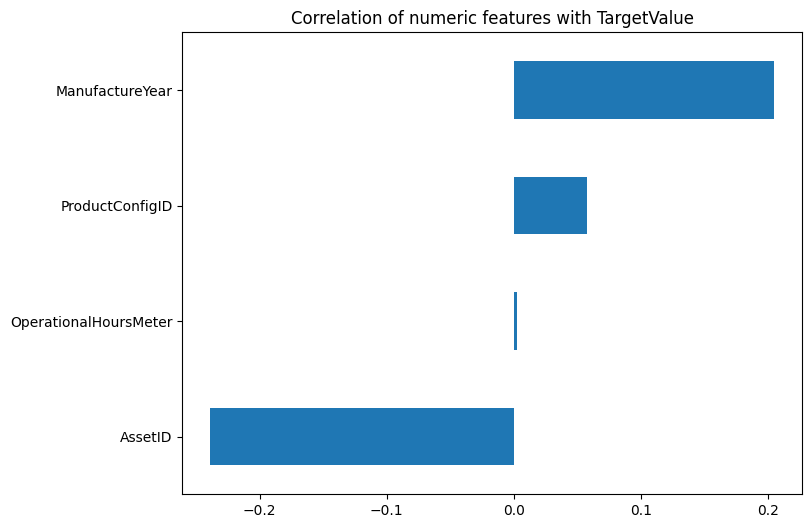

In [7]:
# Numeric feature correlation with target

numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ["TransactionID", "TargetValue"]]

corr_with_target = train[numeric_cols + ["TargetValue"]].corr()["TargetValue"].drop("TargetValue").sort_values(ascending=False)
print(corr_with_target)

plt.figure(figsize=(8, 6))
corr_with_target.plot(kind="barh")
plt.title("Correlation of numeric features with TargetValue")
plt.gca().invert_yaxis()
plt.show()

### 3.5 Categorical Feature Analysis

The number of unique values in each categorical feature is examined to understand categorical cardinality.

This analysis helps distinguish low-cardinality features from high-cardinality features containing many unique equipment categories or identifiers. Cardinality is important when deciding how categorical variables should be represented and which models are suitable for handling them.

TransactionDate              3676
Spec_FullDescriptor          3505
Spec_BaseClass               1249
Spec_SubClass                 147
Spec_VariantModifier          132
Spec_ReleaseSeries            113
FunctionalClassification       65
RegionCode                     53
VendorPartnerID                31
col22                          27
col21                          18
col15                          15
col10                          11
col27                           9
DrivetrainType                  8
DataOriginCode                  6
col7                            6
AssetScaleFactor                6
InventoryGroupDescription       6
InventoryGroupCategory          6
col28                           5
col1                            4
col12                           4
UtilizationTier                 3
col3                            3
col8                            3
col23                           3
CabinType                       3
col25                           3
col24         

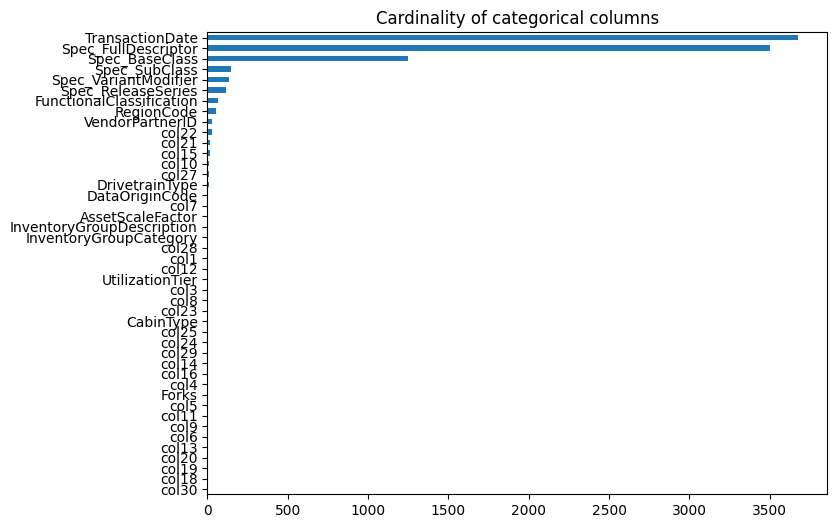

In [8]:
# Categorical cardinality overview

cat_cols_raw = train.select_dtypes(include=["object"]).columns.tolist()
cardinality = train[cat_cols_raw].nunique().sort_values(ascending=False)
print(cardinality)

plt.figure(figsize=(8, 6))
cardinality.plot(kind="barh")
plt.title("Cardinality of categorical columns")
plt.gca().invert_yaxis()
plt.show()

### 3.6 Categorical Features vs. Selling Price

The relationship between selected categorical features and `TargetValue` is examined to determine whether different equipment categories are associated with different selling-price distributions.

Visible differences across categories indicate that categorical information can provide useful predictive signal and should be retained during model development rather than being discarded.

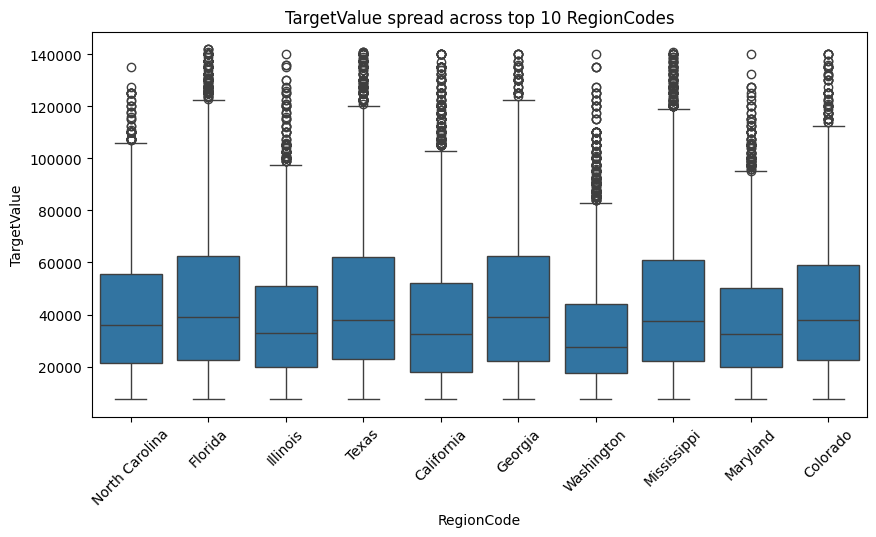

In [9]:
# Bivariate: TargetValue vs a couple of key categoricals

plt.figure(figsize=(10, 5))
top_regions = train["RegionCode"].value_counts().head(10).index
sns.boxplot(data=train[train["RegionCode"].isin(top_regions)], x="RegionCode", y="TargetValue")
plt.xticks(rotation=45)
plt.title("TargetValue spread across top 10 RegionCodes")
plt.show()

### EDA Summary

The exploratory analysis highlights several characteristics that guide the subsequent modelling pipeline:

- `TargetValue` is right-skewed, motivating modelling of the target using a logarithmic transformation.
- Several features contain substantial missing values and require appropriate preprocessing rather than unconditional removal.
- `ManufactureYear` contains anomalous values that should be handled before deriving machine age.
- Numerical features show varying levels of association with selling price.
- The dataset contains both low- and high-cardinality categorical features.
- Selling prices vary across important equipment categories, indicating useful predictive information in the categorical variables.

These observations are used to guide feature engineering and model preparation in the following sections.

## 4. Feature Engineering

New features are derived from the existing variables to represent temporal information, equipment age, missingness patterns, specification completeness, and categorical frequency.

The same feature-engineering logic is applied to both the training and test datasets to maintain a consistent feature space and prevent differences between model training and final prediction.

### 4.1 Core Derived Features

A reusable feature-engineering function is defined so that identical transformations are applied to both training and test data.

The following features are created:

- **TransactionYear** — extracts the year of the transaction.
- **TransactionQuarter** — represents the quarter in which the transaction occurred.
- **ManufactureYearMissing** — flags anomalous manufacturing years below 1900 before they are replaced with missing values.
- **AssetAge** — estimates equipment age at the time of transaction using the difference between transaction year and manufacture year.
- **DescriptorLength** — captures the length of the full specification descriptor.
- **HasOperationalHours** — indicates whether operational-hours information is available.
- **HasVariantModifier** — indicates whether a variant modifier is available.

After extracting the temporal information, the original `TransactionDate` column is removed because its useful components have already been represented numerically.

In [10]:
# Reusable feature engineering function
# applied identically to train and test so nothing drifts apart


def engineer_features(df):
    df = df.copy()

    # dates
    df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])
    df["TransactionYear"] = df["TransactionDate"].dt.year
    df["TransactionQuarter"] = df["TransactionDate"].dt.quarter

    # fix the ManufactureYear=1001 placeholder before using it anywhere
    df["ManufactureYearMissing"] = (df["ManufactureYear"] < 1900).astype(int)
    df.loc[df["ManufactureYear"] < 1900, "ManufactureYear"] = np.nan

    # asset age, now safe from the placeholder blowing it up
    df["AssetAge"] = df["TransactionYear"] - df["ManufactureYear"]
    df.loc[df["AssetAge"] < 0, "AssetAge"] = np.nan

    # descriptor length - keep as NaN when missing, don't let it become "nan" string length
    df["DescriptorLength"] = df["Spec_FullDescriptor"].str.len()

    df["HasOperationalHours"] = df["OperationalHoursMeter"].notna().astype(int)
    df["HasVariantModifier"] = df["Spec_VariantModifier"].notna().astype(int)

    df = df.drop(columns=["TransactionDate"])
    return df

#### Applying Feature Engineering

The feature-engineering function is applied independently to the training and test datasets. Their resulting dimensions are then checked to confirm that the transformations were completed successfully.

In [11]:
train_fe = engineer_features(train)
test_fe = engineer_features(test)

print("train_fe shape:", train_fe.shape)
print("test_fe shape:", test_fe.shape)

train_fe shape: (138701, 56)
test_fe shape: (15000, 55)


### 4.2 Specification Completeness Feature

The dataset contains multiple sparse specification columns (`col1` to `col30`) with substantial missingness.

Instead of treating these columns only as individual specifications, `SpecFilledCount` is created to count how many specification fields are available for each equipment record.

This provides the models with a compact measure of specification completeness, which may contain useful information about the equipment configuration or record quality.

In [12]:
# Sparse spec-column completeness signal (col1-col30 are 75-99% missing,
# equipment-type specific - this counts how many are actually filled per row)


spec_cols = [c for c in train_fe.columns if c.startswith("col")]

train_fe["SpecFilledCount"] = train_fe[spec_cols].notna().sum(axis=1)
test_fe["SpecFilledCount"] = test_fe[spec_cols].notna().sum(axis=1)

print(train_fe["SpecFilledCount"].describe())

count    138701.000000
mean          7.501381
std           2.178354
min           4.000000
25%           6.000000
50%           8.000000
75%           8.000000
max          11.000000
Name: SpecFilledCount, dtype: float64


### 4.3 Frequency Encoding of High-Cardinality Features

Selected high-cardinality categorical features are supplemented with frequency-encoded versions.

For each category, frequency encoding represents how often that value occurs in the training dataset. This provides an additional numerical signal describing whether a category is common or rare without expanding the feature space through one-hot encoding.

Frequency mappings are learned only from the training data and then applied to the test data. Categories appearing in the test set but not observed in training are assigned a frequency of zero.

The original categorical columns are retained because they remain useful for categorical-aware models, while the frequency features provide additional numerical information for the ensemble models.

In [13]:
# Frequency encoding for high-cardinality columns

high_card_cols = ["AssetID", "ProductConfigID", "Spec_FullDescriptor"]

for col in high_card_cols:
    freq_map = train_fe[col].value_counts()
    train_fe[col + "_Freq"] = train_fe[col].map(freq_map)
    test_fe[col + "_Freq"] = test_fe[col].map(freq_map).fillna(0)

print("Final train_fe shape:", train_fe.shape)
print("Final test_fe shape:", test_fe.shape)

Final train_fe shape: (138701, 60)
Final test_fe shape: (15000, 59)


### Feature Engineering Summary

The feature-engineering stage enriches the original dataset with several types of predictive information:

- **Temporal features:** transaction year and quarter.
- **Equipment age:** age of the asset at the time of sale.
- **Data-quality indicators:** flags for anomalous manufacture year and availability of operational hours or variant information.
- **Text-derived information:** descriptor length.
- **Specification completeness:** number of populated specification fields.
- **Category prevalence:** frequency-encoded versions of selected high-cardinality categorical features.

These engineered features are used alongside the original variables during model preparation and training.

## 5. Model Preparation and Train-Validation Split

The feature-engineered dataset is prepared for model training by separating the predictors from the target variable and creating a validation set for model evaluation.

Since CatBoost and XGBoost/LightGBM handle categorical variables differently, separate feature representations are prepared while keeping the same underlying observations and validation split.

The target variable is transformed using `log1p` so that the models learn selling prices on the logarithmic scale, consistent with the RMSLE-based evaluation strategy.

### 5.1 Predictor and Target Preparation

The feature matrix `X` is created by removing `TargetValue` from the feature-engineered training dataset.

The target `y` is transformed using `log1p(TargetValue)`. Training in log space reduces the influence of very large selling prices and aligns the modelling objective more closely with RMSLE, which evaluates errors on a logarithmic scale.

In [14]:
# Base X / y

X = train_fe.drop("TargetValue", axis=1)
y = np.log1p(train_fe["TargetValue"])

### 5.2 Feature Alignment and Categorical Detection

Before model preparation, the test dataset is aligned with the training feature matrix so that both contain the same features in the same order.

An assertion is used as a safety check to stop execution if the training and test feature structures do not match.

Categorical features are then identified automatically from columns stored with the `object` data type. These columns require model-specific preparation before training.

In [15]:
test_fe = test_fe[X.columns]  # lock column order to match X right away
assert list(X.columns) == list(test_fe.columns), "columns don't match, stop here"

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
print("categorical columns:", len(cat_cols))

categorical columns: 43


### 5.3 CatBoost Data Preparation

A separate feature representation is created for CatBoost because CatBoost can directly process categorical features.

Missing values in categorical columns are replaced with the explicit category `"Missing"`, and the values are converted to strings. The column positions of categorical features are then recorded so they can be supplied to CatBoost during training.

The data is divided into 80% training and 20% validation data using a fixed `random_state` for reproducibility.

In [16]:
# Version for CatBoost - raw strings, filled with "Missing"

X_cb = X.copy()
test_cb = test_fe.copy()

for col in cat_cols:
    X_cb[col] = X_cb[col].fillna("Missing").astype(str)
    test_cb[col] = test_cb[col].fillna("Missing").astype(str)

cat_feature_indices = [X_cb.columns.get_loc(col) for col in cat_cols]

X_train_cb, X_valid_cb, y_train, y_valid = train_test_split(
    X_cb, y, test_size=0.2, random_state=42
)

### 5.4 XGBoost and LightGBM Data Preparation

A second feature representation is prepared for XGBoost and LightGBM.

Missing categorical values are again represented using `"Missing"`, but these columns are converted to Pandas `category` data type instead of strings. This representation is used by the categorical-feature support enabled later in the XGBoost and LightGBM models.

The test categories are explicitly aligned with the categories learned from the training data to ensure consistent categorical representation.

The same 80/20 split and `random_state=42` are used so that all three models are evaluated on the same validation observations.

In [17]:
# Version for XGBoost / LightGBM - category dtype
# both use the same category-based version, so we only build it once


X_tree = X.copy()
test_tree = test_fe.copy()

for col in cat_cols:
    X_tree[col] = X_tree[col].fillna("Missing").astype("category")
    test_tree[col] = test_tree[col].fillna("Missing").astype("category")
    # make sure test categories match train categories exactly
    test_tree[col] = test_tree[col].cat.set_categories(X_tree[col].cat.categories)

X_train_tree, X_valid_tree, _, _ = train_test_split(
    X_tree, y, test_size=0.2, random_state=42
)

print("X_train_cb:", X_train_cb.shape, "| X_train_tree:", X_train_tree.shape)

X_train_cb: (110960, 59) | X_train_tree: (110960, 59)


### Model Preparation Summary

Two model-specific versions of the same feature matrix are prepared:

- **CatBoost:** categorical variables are represented as strings and their column indices are supplied to the model.
- **XGBoost and LightGBM:** categorical variables are represented using Pandas `category` dtype with training and test category levels aligned.

All models use the same 80/20 training-validation split, allowing their validation performance to be compared fairly.

## 6. Baseline Model Training

Three gradient boosting models — CatBoost, XGBoost, and LightGBM — are first trained using fixed baseline hyperparameters.

These baseline models establish an initial performance benchmark before hyperparameter tuning. All three models are evaluated on the same validation split using RMSLE, allowing their performance to be compared consistently.

Early stopping is used during training to stop adding boosting iterations when validation performance no longer improves.

### 6.1 CatBoost Baseline

CatBoost is trained as the first baseline model. It is well suited to this dataset because it can directly handle the categorical features prepared earlier without requiring one-hot encoding.

The model is configured with a maximum of 4000 boosting iterations, a learning rate of 0.03, tree depth of 8, and L2 regularization of 3.

A validation set is supplied during training, and early stopping terminates training if validation RMSE does not improve for 150 consecutive iterations. `use_best_model=True` retains the iteration with the best validation performance.

In [18]:
# CatBoost - baseline

model_cb = CatBoostRegressor(
    iterations=4000,
    learning_rate=0.03,
    depth=8,
    l2_leaf_reg=3,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=300,
    early_stopping_rounds=150
)

model_cb.fit(
    X_train_cb, y_train,
    cat_features=cat_feature_indices,
    eval_set=(X_valid_cb, y_valid),
    use_best_model=True
)

0:	learn: 0.6580704	test: 0.6562040	best: 0.6562040 (0)	total: 779ms	remaining: 51m 53s
300:	learn: 0.2472856	test: 0.2414065	best: 0.2414065 (300)	total: 3m 30s	remaining: 43m 6s
600:	learn: 0.2282966	test: 0.2255535	best: 0.2255535 (600)	total: 7m 11s	remaining: 40m 39s
900:	learn: 0.2194144	test: 0.2193425	best: 0.2193425 (900)	total: 10m 55s	remaining: 37m 33s
1200:	learn: 0.2136503	test: 0.2157365	best: 0.2157365 (1200)	total: 14m 39s	remaining: 34m 9s
1500:	learn: 0.2094389	test: 0.2134784	best: 0.2134784 (1500)	total: 18m 24s	remaining: 30m 38s
1800:	learn: 0.2061446	test: 0.2118305	best: 0.2118305 (1800)	total: 22m 8s	remaining: 27m 1s
2100:	learn: 0.2030461	test: 0.2104880	best: 0.2104880 (2100)	total: 25m 50s	remaining: 23m 21s
2400:	learn: 0.2003256	test: 0.2094568	best: 0.2094568 (2400)	total: 29m 33s	remaining: 19m 41s
2700:	learn: 0.1979470	test: 0.2085946	best: 0.2085946 (2700)	total: 33m 16s	remaining: 16m
3000:	learn: 0.1957267	test: 0.2078726	best: 0.2078726 (3000)	to

CatBoostRegressor(depth=8, early_stopping_rounds=150, eval_metric='RMSE', iterations=4000, l2_leaf_reg=3, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=300)

#### CatBoost Validation Performance

Predictions on the validation set are initially produced in logarithmic space because the model was trained on `log1p(TargetValue)`.

`expm1` is therefore applied to both the predictions and validation target to return them to the original selling-price scale. RMSLE is then calculated between the actual and predicted selling prices.

A lower RMSLE indicates better predictive performance.

In [19]:
# Validation RMSLE

pred_valid_cb = np.expm1(model_cb.predict(X_valid_cb))
y_valid_original = np.expm1(y_valid)

rmsle_cb = np.sqrt(mean_squared_log_error(y_valid_original, pred_valid_cb))
print("CatBoost Validation RMSLE:", rmsle_cb)

CatBoost Validation RMSLE: 0.20602448190336947


### 6.2 XGBoost Baseline

XGBoost is trained as the second baseline model using the categorical feature representation prepared earlier.

The baseline uses 3000 maximum boosting estimators, a learning rate of 0.03, maximum tree depth of 8, row subsampling of 0.8, column subsampling of 0.8, and L2 regularization of 3.

The histogram-based tree method is used together with categorical-feature support. Early stopping is applied using the validation set so that training can terminate when validation performance stops improving.

In [20]:
# XGBoost - baseline

model_xgb = xgb.XGBRegressor(
    n_estimators=3000,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=3,
    tree_method="hist",
    enable_categorical=True,
    eval_metric="rmse",
    early_stopping_rounds=100,
    random_state=42
)

model_xgb.fit(
    X_train_tree, y_train,
    eval_set=[(X_valid_tree, y_valid)],
    verbose=300
)

[0]	validation_0-rmse:0.65343
[300]	validation_0-rmse:0.21167
[600]	validation_0-rmse:0.20775
[900]	validation_0-rmse:0.20641
[1200]	validation_0-rmse:0.20559
[1500]	validation_0-rmse:0.20526
[1800]	validation_0-rmse:0.20496
[2100]	validation_0-rmse:0.20491
[2400]	validation_0-rmse:0.20484
[2474]	validation_0-rmse:0.20485


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=100,
             enable_categorical=True, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=3000,
             n_jobs=None, num_parallel_tree=None, ...)

#### XGBoost Validation Performance

XGBoost predictions are generated for the same validation observations used for CatBoost.

Since the model is also trained using the log-transformed target, `expm1` converts its predictions back to the original selling-price scale before RMSLE is calculated.

In [21]:
# Validation RMSLE

pred_valid_xgb = np.expm1(model_xgb.predict(X_valid_tree))

rmsle_xgb = np.sqrt(mean_squared_log_error(y_valid_original, pred_valid_xgb))
print("XGBoost Validation RMSLE:", rmsle_xgb)

XGBoost Validation RMSLE: 0.2048309684842896


### 6.3 LightGBM Baseline

LightGBM is trained as the third baseline model using the same training and validation observations as XGBoost.

The baseline uses up to 3000 boosting estimators, a learning rate of 0.03, maximum depth of 8, 64 leaves, row subsampling of 0.8, column subsampling of 0.8, and L2 regularization of 3.

The categorical columns are explicitly supplied to LightGBM, and early stopping is used to stop training when validation RMSE does not improve for 100 rounds.

In [22]:
# LightGBM - baseline

model_lgb = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.03,
    max_depth=8,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=3,
    random_state=42,
    verbose=-1
)

model_lgb.fit(
    X_train_tree, y_train,
    eval_set=[(X_valid_tree, y_valid)],
    eval_metric="rmse",
    categorical_feature=cat_cols,
    callbacks=[lgb.early_stopping(stopping_rounds=100), lgb.log_evaluation(period=300)]
)

Training until validation scores don't improve for 100 rounds
[300]	valid_0's rmse: 0.215904	valid_0's l2: 0.0466146
[600]	valid_0's rmse: 0.209657	valid_0's l2: 0.0439562
[900]	valid_0's rmse: 0.207082	valid_0's l2: 0.042883
[1200]	valid_0's rmse: 0.20545	valid_0's l2: 0.0422097
[1500]	valid_0's rmse: 0.204302	valid_0's l2: 0.0417392
[1800]	valid_0's rmse: 0.203465	valid_0's l2: 0.0413981
[2100]	valid_0's rmse: 0.202946	valid_0's l2: 0.041187
[2400]	valid_0's rmse: 0.20252	valid_0's l2: 0.0410143
[2700]	valid_0's rmse: 0.202284	valid_0's l2: 0.0409186
[3000]	valid_0's rmse: 0.202055	valid_0's l2: 0.0408261
Did not meet early stopping. Best iteration is:
[2999]	valid_0's rmse: 0.202053	valid_0's l2: 0.0408256


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.03, max_depth=8,
              n_estimators=3000, num_leaves=64, random_state=42, reg_lambda=3,
              subsample=0.8, verbose=-1)

#### LightGBM Validation Performance

LightGBM predictions are generated on the common validation set and converted from log space back to the original selling-price scale.

RMSLE is calculated using the same validation target and evaluation procedure as CatBoost and XGBoost, ensuring a fair baseline comparison.

In [23]:
# Validation RMSLE

pred_valid_lgb = np.expm1(model_lgb.predict(X_valid_tree))

rmsle_lgb = np.sqrt(mean_squared_log_error(y_valid_original, pred_valid_lgb))
print("LightGBM Validation RMSLE:", rmsle_lgb)

LightGBM Validation RMSLE: 0.20205346406188726


### 6.4 Baseline Model Comparison

The validation RMSLE values of CatBoost, XGBoost, and LightGBM are compared to establish the baseline performance of each model.

The models are ranked by validation RMSLE, where a lower value represents better performance. The comparison provides a reference point for determining whether subsequent hyperparameter tuning improves model performance.

      Model  Validation_RMSLE
0  LightGBM          0.202053
1   XGBoost          0.204831
2  CatBoost          0.206024


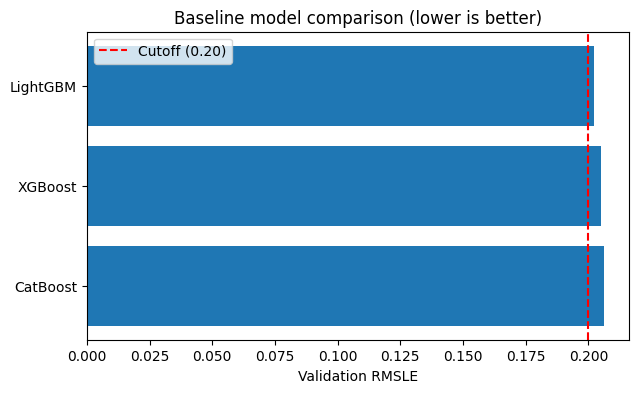

In [24]:
# Baseline comparison - all three models, same validation split

results_baseline = pd.DataFrame({
    "Model": ["CatBoost", "XGBoost", "LightGBM"],
    "Validation_RMSLE": [rmsle_cb, rmsle_xgb, rmsle_lgb]
}).sort_values("Validation_RMSLE").reset_index(drop=True)

print(results_baseline)

plt.figure(figsize=(7, 4))
plt.barh(results_baseline["Model"], results_baseline["Validation_RMSLE"])
plt.xlabel("Validation RMSLE")
plt.title("Baseline model comparison (lower is better)")
plt.axvline(0.20, color="red", linestyle="--", label="Cutoff (0.20)")
plt.legend()
plt.gca().invert_yaxis()
plt.show()

## 7. Hyperparameter Tuning with Cross-Validation

After establishing baseline performance, hyperparameter tuning is performed using
RandomizedSearchCV with 3-fold cross-validation.

Unlike the earlier baseline models, where fixed hyperparameters were used,
RandomizedSearchCV evaluates multiple combinations of hyperparameters and
selects the configuration with the best cross-validation performance.

The target variable is log-transformed, so RMSE on the transformed target is
used as the cross-validation scoring metric. This is consistent with the RMSLE
evaluation used throughout the notebook because:

RMSLE = RMSE(log(1 + actual), log(1 + predicted))

Three models are tuned independently:

- CatBoost
- XGBoost
- LightGBM

The search spaces contain parameters controlling tree complexity, learning rate,
regularization and row/feature sampling. A fixed random state is used to make
the search reproducible.

The final selected models are subsequently evaluated on the common validation
set using RMSLE.

### 7.1 CatBoost Hyperparameter Tuning

CatBoost hyperparameters are tuned using RandomizedSearchCV with 3-fold
cross-validation.

The search focuses on parameters that directly affect model complexity and
regularization:

- `depth` controls the depth of the individual trees.
- `learning_rate` controls the contribution of each boosting iteration.
- `l2_leaf_reg` controls L2 regularization.
- `iterations` controls the maximum number of boosting iterations.

A sufficiently large search space is used so that the tuning process explores
meaningfully different CatBoost configurations rather than only reproducing
the baseline model.

In [25]:
# CatBoost hyperparameter tuning using RandomizedSearchCV

X_hpt = X_train_cb.sample(
    n=25000,
    random_state=42
)

y_hpt = y_train.loc[X_hpt.index]

cb_base = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=False,
    thread_count=-1
)

cb_param_dist = {
    "depth": [7, 8, 9],
    "l2_leaf_reg": [1, 3, 5]
}

cv = KFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

cb_search = RandomizedSearchCV(
    estimator=cb_base,
    param_distributions=cb_param_dist,
    n_iter=3,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=42,
    n_jobs=1,
    verbose=2,
    refit=False
)

cb_search.fit(
    X_hpt,
    y_hpt,
    cat_features=cat_feature_indices
)

print("Best CatBoost parameters:")
print(cb_search.best_params_)

print("\nBest CatBoost CV RMSE:")
print(-cb_search.best_score_)

Fitting 3 folds for each of 3 candidates, totalling 9 fits
[CV] END .............................depth=9, l2_leaf_reg=3; total time= 3.4min
[CV] END .............................depth=9, l2_leaf_reg=3; total time= 3.4min
[CV] END .............................depth=9, l2_leaf_reg=3; total time= 3.3min
[CV] END .............................depth=7, l2_leaf_reg=3; total time= 1.9min
[CV] END .............................depth=7, l2_leaf_reg=3; total time= 1.9min
[CV] END .............................depth=7, l2_leaf_reg=3; total time= 1.9min
[CV] END .............................depth=8, l2_leaf_reg=5; total time= 2.5min
[CV] END .............................depth=8, l2_leaf_reg=5; total time= 2.5min
[CV] END .............................depth=8, l2_leaf_reg=5; total time= 2.4min
Best CatBoost parameters:
{'l2_leaf_reg': 3, 'depth': 9}

Best CatBoost CV RMSE:
0.2399803747861765


In [26]:
# Refit CatBoost using the best hyperparameters on the complete training data

best_cb_params = cb_search.best_params_

model_cb = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=200,
    thread_count=-1,
    iterations=3000,
    learning_rate=0.03,
    depth=best_cb_params["depth"],
    l2_leaf_reg=best_cb_params["l2_leaf_reg"]
)

model_cb.fit(
    X_train_cb,
    y_train,
    cat_features=cat_feature_indices,
    eval_set=(X_valid_cb, y_valid),
    use_best_model=True,
    early_stopping_rounds=100
)

print("\nFinal CatBoost parameters:")
print(model_cb.get_params())

0:	learn: 0.6577258	test: 0.6558594	best: 0.6558594 (0)	total: 857ms	remaining: 42m 49s
200:	learn: 0.2521083	test: 0.2466307	best: 0.2466307 (200)	total: 2m 51s	remaining: 39m 46s
400:	learn: 0.2320661	test: 0.2294669	best: 0.2294669 (400)	total: 5m 58s	remaining: 38m 40s
600:	learn: 0.2203723	test: 0.2210903	best: 0.2210903 (600)	total: 9m 3s	remaining: 36m 9s
800:	learn: 0.2136361	test: 0.2169545	best: 0.2169545 (800)	total: 12m 11s	remaining: 33m 28s
1000:	learn: 0.2092507	test: 0.2145926	best: 0.2145926 (1000)	total: 15m 20s	remaining: 30m 37s
1200:	learn: 0.2052475	test: 0.2126851	best: 0.2126851 (1200)	total: 18m 27s	remaining: 27m 38s
1400:	learn: 0.2020822	test: 0.2113293	best: 0.2113293 (1400)	total: 21m 37s	remaining: 24m 41s
1600:	learn: 0.1990653	test: 0.2101441	best: 0.2101441 (1600)	total: 24m 45s	remaining: 21m 38s
1800:	learn: 0.1964449	test: 0.2091642	best: 0.2091642 (1800)	total: 27m 55s	remaining: 18m 35s
2000:	learn: 0.1940865	test: 0.2083700	best: 0.2083700 (2000)

### 7.2 XGBoost Hyperparameter Tuning

XGBoost is tuned using RandomizedSearchCV with 3-fold cross-validation.

A representative subset of the training data is used for the hyperparameter
search to reduce computational cost while preserving the tuning workflow.

The search focuses on `max_depth` and `min_child_weight`, which control tree
complexity and the minimum amount of information required for further
splitting.

After identifying the best hyperparameters, the XGBoost model is refitted on
the complete training dataset.

In [27]:
# XGBoost hyperparameter tuning using RandomizedSearchCV

X_hpt_xgb = X_train_tree.sample(
    n=25000,
    random_state=42
)

y_hpt_xgb = y_train.loc[X_hpt_xgb.index]

xgb_base = xgb.XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    enable_categorical=True,
    eval_metric="rmse",
    random_state=42,
    n_jobs=-1
)

xgb_param_dist = {
    "max_depth": [7, 8, 9],
    "min_child_weight": [3, 5, 7]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_dist,
    n_iter=3,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=42,
    n_jobs=1,
    verbose=2,
    refit=False
)

xgb_search.fit(
    X_hpt_xgb,
    y_hpt_xgb
)

print("Best XGBoost parameters:")
print(xgb_search.best_params_)

print("\nBest XGBoost CV RMSE:")
print(-xgb_search.best_score_)

Fitting 3 folds for each of 3 candidates, totalling 9 fits
[CV] END ....................max_depth=9, min_child_weight=5; total time=   5.6s
[CV] END ....................max_depth=9, min_child_weight=5; total time=   5.6s
[CV] END ....................max_depth=9, min_child_weight=5; total time=   5.7s
[CV] END ....................max_depth=7, min_child_weight=5; total time=   3.0s
[CV] END ....................max_depth=7, min_child_weight=5; total time=   2.9s
[CV] END ....................max_depth=7, min_child_weight=5; total time=   3.0s
[CV] END ....................max_depth=8, min_child_weight=7; total time=   4.1s
[CV] END ....................max_depth=8, min_child_weight=7; total time=   4.2s
[CV] END ....................max_depth=8, min_child_weight=7; total time=   4.0s
Best XGBoost parameters:
{'min_child_weight': 7, 'max_depth': 8}

Best XGBoost CV RMSE:
0.2520691781026938


In [28]:
# Refit XGBoost using the best hyperparameters on the complete training data

best_xgb_params = xgb_search.best_params_

model_xgb = xgb.XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    enable_categorical=True,
    eval_metric="rmse",
    random_state=42,
    n_jobs=-1,
    n_estimators=3000,
    learning_rate=0.03,
    max_depth=best_xgb_params["max_depth"],
    min_child_weight=best_xgb_params["min_child_weight"],
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=3
)

model_xgb.fit(
    X_train_tree,
    y_train,
    eval_set=[(X_valid_tree, y_valid)],
    verbose=300
)

print("\nFinal XGBoost parameters:")
print(model_xgb.get_params())

[0]	validation_0-rmse:0.65352
[300]	validation_0-rmse:0.21313
[600]	validation_0-rmse:0.20853
[900]	validation_0-rmse:0.20673
[1200]	validation_0-rmse:0.20549
[1500]	validation_0-rmse:0.20484
[1800]	validation_0-rmse:0.20435
[2100]	validation_0-rmse:0.20407
[2400]	validation_0-rmse:0.20382
[2700]	validation_0-rmse:0.20369
[2999]	validation_0-rmse:0.20365

Final XGBoost parameters:
{'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.8, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': True, 'eval_metric': 'rmse', 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.03, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 8, 'max_leaves': None, 'min_child_weight': 7, 'missing': nan, 'monotone_const

### 7.3 LightGBM Hyperparameter Tuning

LightGBM is tuned using RandomizedSearchCV with 3-fold cross-validation.

A representative subset of the training data is used during the search to
control computational cost.

The search focuses on `num_leaves` and `min_child_samples`, which control
tree complexity and the minimum number of observations required in a leaf.

After identifying the best hyperparameters, the LightGBM model is refitted
on the complete training dataset.

In [29]:
# LightGBM hyperparameter tuning using RandomizedSearchCV

X_hpt_lgb = X_train_tree.sample(
    n=25000,
    random_state=42
)

y_hpt_lgb = y_train.loc[X_hpt_lgb.index]

lgb_base = lgb.LGBMRegressor(
    objective="regression",
    random_state=42,
    verbose=-1,
    n_jobs=-1
)

lgb_param_dist = {
    "num_leaves": [48, 64, 96],
    "min_child_samples": [20, 30, 40]
}

lgb_search = RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=lgb_param_dist,
    n_iter=3,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=42,
    n_jobs=1,
    verbose=2,
    refit=False
)

lgb_search.fit(
    X_hpt_lgb,
    y_hpt_lgb,
    categorical_feature=cat_cols
)

print("Best LightGBM parameters:")
print(lgb_search.best_params_)

print("\nBest LightGBM CV RMSE:")
print(-lgb_search.best_score_)

Fitting 3 folds for each of 3 candidates, totalling 9 fits
[CV] END ................min_child_samples=40, num_leaves=64; total time=   1.0s
[CV] END ................min_child_samples=40, num_leaves=64; total time=   1.0s
[CV] END ................min_child_samples=40, num_leaves=64; total time=   1.0s
[CV] END ................min_child_samples=20, num_leaves=64; total time=   1.0s
[CV] END ................min_child_samples=20, num_leaves=64; total time=   1.0s
[CV] END ................min_child_samples=20, num_leaves=64; total time=   1.1s
[CV] END ................min_child_samples=30, num_leaves=96; total time=   1.3s
[CV] END ................min_child_samples=30, num_leaves=96; total time=   1.2s
[CV] END ................min_child_samples=30, num_leaves=96; total time=   1.2s
Best LightGBM parameters:
{'num_leaves': 96, 'min_child_samples': 30}

Best LightGBM CV RMSE:
0.23956320865126565


In [30]:
# Refit LightGBM using the best hyperparameters on the complete training data

best_lgb_params = lgb_search.best_params_

model_lgb = lgb.LGBMRegressor(
    objective="regression",
    random_state=42,
    verbose=-1,
    n_jobs=-1,
    n_estimators=3000,
    learning_rate=0.03,
    num_leaves=best_lgb_params["num_leaves"],
    min_child_samples=best_lgb_params["min_child_samples"],
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=3
)

model_lgb.fit(
    X_train_tree,
    y_train,
    eval_set=[(X_valid_tree, y_valid)],
    callbacks=[
        lgb.early_stopping(100),
        lgb.log_evaluation(300)
    ],
    categorical_feature=cat_cols
)

print("\nFinal LightGBM parameters:")
print(model_lgb.get_params())

Training until validation scores don't improve for 100 rounds
[300]	valid_0's l2: 0.0461251
[600]	valid_0's l2: 0.0435028
[900]	valid_0's l2: 0.0425442
[1200]	valid_0's l2: 0.0418596
[1500]	valid_0's l2: 0.0413795
[1800]	valid_0's l2: 0.0411545
[2100]	valid_0's l2: 0.0409726
[2400]	valid_0's l2: 0.0408322
[2700]	valid_0's l2: 0.0407596
[3000]	valid_0's l2: 0.040708
Did not meet early stopping. Best iteration is:
[2998]	valid_0's l2: 0.0407076

Final LightGBM parameters:
{'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 0.8, 'importance_type': 'split', 'learning_rate': 0.03, 'max_depth': 8, 'min_child_samples': 30, 'min_child_weight': 0.001, 'min_split_gain': 0.0, 'n_estimators': 3000, 'n_jobs': -1, 'num_leaves': 96, 'objective': 'regression', 'random_state': 42, 'reg_alpha': 0.0, 'reg_lambda': 3, 'subsample': 0.8, 'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbose': -1}


### 7.4 Hyperparameter Search Summary

All three models were tuned using RandomizedSearchCV with 3-fold
cross-validation.

The search evaluates multiple combinations from predefined parameter
distributions and selects the configuration with the best cross-validation
RMSE.

The validation set is not used during the cross-validation search. It is
reserved for the subsequent final comparison of the tuned models using RMSLE.

This provides a consistent evaluation procedure across CatBoost, XGBoost,
and LightGBM.

In [31]:
# Summary of cross-validation search results

hpt_summary = pd.DataFrame({
    "Model": ["CatBoost", "XGBoost", "LightGBM"],
    "Best_CV_RMSE": [
        -cb_search.best_score_,
        -xgb_search.best_score_,
        -lgb_search.best_score_
    ]
}).sort_values("Best_CV_RMSE").reset_index(drop=True)

print(hpt_summary)

      Model  Best_CV_RMSE
0  LightGBM      0.239563
1  CatBoost      0.239980
2   XGBoost      0.252069


## 8. Tuned Model Comparison and Ensemble Evaluation

After cross-validated hyperparameter tuning, the selected CatBoost, XGBoost,
and LightGBM models are evaluated on the same held-out validation set.

All three models were trained using the log-transformed target. Their
predictions are therefore converted back to the original selling-price scale
using `expm1` before calculating RMSLE.

A lower RMSLE indicates better predictive performance.

### 8.1 Tuned Model Performance

The tuned models are evaluated independently on the common validation set.

Using the same validation observations for all three models ensures that
their RMSLE values can be compared fairly.

The models are ranked from lowest to highest validation RMSLE.

In [32]:
# Validation predictions from the tuned models

pred_valid_cb = np.clip(
    np.expm1(model_cb.predict(X_valid_cb)),
    0,
    None
)

pred_valid_xgb = np.clip(
    np.expm1(model_xgb.predict(X_valid_tree)),
    0,
    None
)

pred_valid_lgb = np.clip(
    np.expm1(model_lgb.predict(X_valid_tree)),
    0,
    None
)

# Calculate validation RMSLE

rmsle_cb = np.sqrt(
    mean_squared_log_error(y_valid_original, pred_valid_cb)
)

rmsle_xgb = np.sqrt(
    mean_squared_log_error(y_valid_original, pred_valid_xgb)
)

rmsle_lgb = np.sqrt(
    mean_squared_log_error(y_valid_original, pred_valid_lgb)
)

# Comparison table

results_tuned = pd.DataFrame({
    "Model": ["CatBoost", "XGBoost", "LightGBM"],
    "Validation_RMSLE": [
        rmsle_cb,
        rmsle_xgb,
        rmsle_lgb
    ]
}).sort_values(
    "Validation_RMSLE"
).reset_index(drop=True)

print(results_tuned)

      Model  Validation_RMSLE
0  LightGBM          0.201761
1   XGBoost          0.203647
2  CatBoost          0.205697


### 8.2 Tuned Model Comparison

The validation RMSLE of the three tuned models is visualized below.
Lower RMSLE represents better performance.

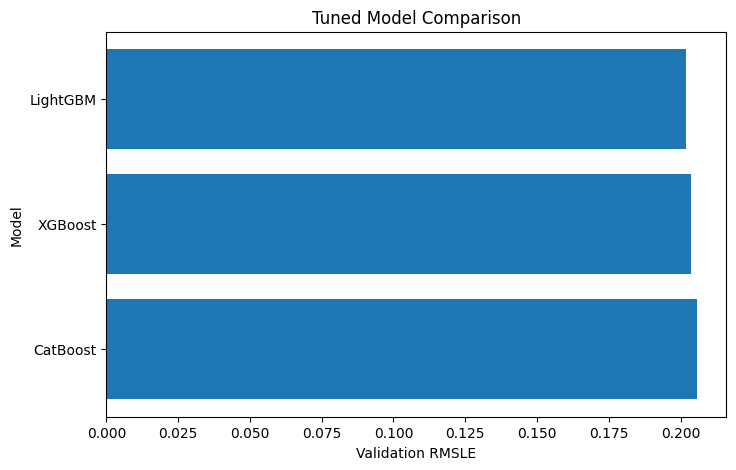

In [33]:
plt.figure(figsize=(8, 5))

plt.barh(
    results_tuned["Model"],
    results_tuned["Validation_RMSLE"]
)

plt.xlabel("Validation RMSLE")
plt.ylabel("Model")
plt.title("Tuned Model Comparison")

plt.gca().invert_yaxis()
plt.show()

### 8.3 Equal-Weight Ensemble

The predictions of the three tuned models are combined using an equal-weight
average.

Each model contributes one-third of the final prediction.

Ensembling can improve generalization when different models capture different
patterns in the data or make different prediction errors.

In [34]:
# Equal-weight ensemble

blend_valid_pred = (
    pred_valid_cb +
    pred_valid_xgb +
    pred_valid_lgb
) / 3

rmsle_blend_equal = np.sqrt(
    mean_squared_log_error(
        y_valid_original,
        blend_valid_pred
    )
)

print("Equal-weight blend RMSLE:", rmsle_blend_equal)

Equal-weight blend RMSLE: 0.1978828678710255


### 8.4 Weighted Ensemble

A second ensemble is created using unequal model weights.

CatBoost contributes 40% of the final prediction, while XGBoost and LightGBM
each contribute 30%.

The weighted ensemble is evaluated using the same validation RMSLE metric and
is compared against the individual tuned models and the equal-weight ensemble.

In [35]:
# Weighted ensemble

weights = {"cb": 0.4, "xgb": 0.3, "lgb": 0.3}

blend_valid_pred_weighted = (
    weights["cb"] * pred_valid_cb +
    weights["xgb"] * pred_valid_xgb +
    weights["lgb"] * pred_valid_lgb
)

rmsle_blend_weighted = np.sqrt(
    mean_squared_log_error(
        y_valid_original,
        blend_valid_pred_weighted
    )
)

print("Weighted blend RMSLE:", rmsle_blend_weighted)

Weighted blend RMSLE: 0.19786336902383944


### 8.5 Overall Validation Performance

The individual tuned models and the two ensemble strategies are compared
using validation RMSLE.

The approach with the lowest validation RMSLE provides the strongest
performance on the held-out validation set.

In [36]:
# Compare all tuned models and ensemble strategies

final_comparison = pd.DataFrame({
    "Approach": [
        "CatBoost",
        "XGBoost",
        "LightGBM",
        "EqualBlend",
        "WeightedBlend"
    ],
    "Validation_RMSLE": [
        rmsle_cb,
        rmsle_xgb,
        rmsle_lgb,
        rmsle_blend_equal,
        rmsle_blend_weighted
    ]
}).sort_values(
    "Validation_RMSLE"
).reset_index(drop=True)

print(final_comparison)

        Approach  Validation_RMSLE
0  WeightedBlend          0.197863
1     EqualBlend          0.197883
2       LightGBM          0.201761
3        XGBoost          0.203647
4       CatBoost          0.205697


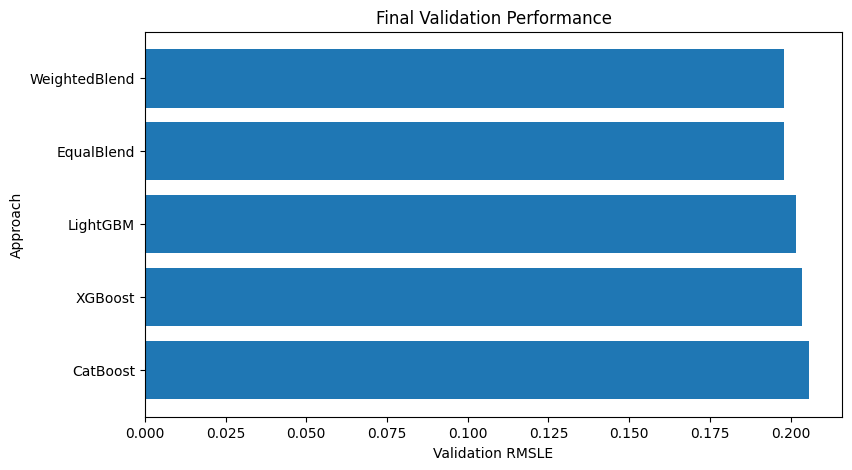

In [37]:
plt.figure(figsize=(9, 5))

plt.barh(
    final_comparison["Approach"],
    final_comparison["Validation_RMSLE"]
)

plt.xlabel("Validation RMSLE")
plt.ylabel("Approach")
plt.title("Final Validation Performance")

plt.gca().invert_yaxis()
plt.show()

### Ensemble Evaluation Summary

The tuned models are evaluated both individually and as ensembles.

Two ensemble strategies are considered:

- **Equal-weight blend:** each model contributes equally to the prediction.
- **Weighted blend:** CatBoost contributes 40%, while XGBoost and LightGBM contribute 30% each.

The validation RMSLE values of these ensemble strategies can be compared with the individual tuned models to determine whether combining model predictions provides an improvement.

## 9. Final Model Selection and Submission

The tuned individual models and ensemble strategies are compared using the
same held-out validation set.

The approach with the lowest validation RMSLE is selected automatically as
the final prediction strategy.

The selected strategy is then applied to the test dataset.

### 9.1 Final Approach Selection

The tuned CatBoost, XGBoost, and LightGBM models are compared with the equal-weight and weighted ensemble strategies.

Validation RMSLE is recalculated from the predictions of the selected tuned models so that every candidate is evaluated using the same models and validation data.

The candidate with the lowest validation RMSLE is automatically selected as the final prediction approach.

In [38]:
# Select the approach with the lowest validation RMSLE

candidates = {
    "CatBoost": rmsle_cb,
    "XGBoost": rmsle_xgb,
    "LightGBM": rmsle_lgb,
    "EqualBlend": rmsle_blend_equal,
    "WeightedBlend": rmsle_blend_weighted
}

best_approach = min(
    candidates,
    key=candidates.get
)

print(
    "Best approach:",
    best_approach,
    "| RMSLE:",
    candidates[best_approach]
)

Best approach: WeightedBlend | RMSLE: 0.19786336902383944


### 9.2 Test Set Predictions

The three tuned models are used to generate predictions for the competition
test set.

Because the models were trained on the log-transformed target, predictions
are converted back to the original price scale using `expm1`.

Negative predictions are clipped to zero because selling prices cannot be
negative.

In [39]:
# Predict on the real test set with each model

test_pred_cb = np.clip(np.expm1(model_cb.predict(test_cb)), 0, None)
test_pred_xgb = np.clip(np.expm1(model_xgb.predict(test_tree)), 0, None)
test_pred_lgb = np.clip(np.expm1(model_lgb.predict(test_tree)), 0, None)

### 9.3 Test Ensemble Predictions

The same ensemble strategies evaluated on the validation set are applied to
the test predictions.

This keeps the test-time prediction procedure consistent with the validation
evaluation.

In [40]:
# Equal-weight test ensemble

test_pred_equal_blend = (
    test_pred_cb +
    test_pred_xgb +
    test_pred_lgb
) / 3


# Weighted test ensemble

test_pred_weighted_blend = (
    weights["cb"] * test_pred_cb +
    weights["xgb"] * test_pred_xgb +
    weights["lgb"] * test_pred_lgb
)

### 9.4 Submission Generation

The prediction corresponding to the best validation approach is selected
automatically.

The final predictions are combined with the required `TransactionID` column
and saved as `submission.csv`.

In [41]:
# Map each validation strategy to its corresponding test predictions

final_pred_map = {
    "CatBoost": test_pred_cb,
    "XGBoost": test_pred_xgb,
    "LightGBM": test_pred_lgb,
    "EqualBlend": test_pred_equal_blend,
    "WeightedBlend": test_pred_weighted_blend
}

final_pred = final_pred_map[best_approach]

submission = pd.DataFrame({
    "TransactionID": test_fe["TransactionID"],
    "TargetValue": final_pred
})

submission.to_csv(
    "submission.csv",
    index=False
)

print(
    "Saved submission.csv using:",
    best_approach
)

submission.head()

Saved submission.csv using: WeightedBlend


,TransactionID,TargetValue
0,1139307,67579.471569
1,1139419,77957.283003
2,1139482,31196.070132
3,1139522,19575.371092
4,1139684,11721.995889


## 10. Conclusion

This project developed a complete regression pipeline for predicting heavy-equipment selling prices.

The workflow included exploratory data analysis, feature engineering, model-specific categorical preparation, baseline modelling, hyperparameter tuning, and ensemble evaluation.

CatBoost, XGBoost, and LightGBM were first evaluated individually using validation RMSLE. Selected hyperparameters were then tuned, after which equal-weight and weighted ensembles were evaluated alongside the tuned models.

The approach achieving the lowest validation RMSLE was selected automatically and used to generate the final test predictions. The predictions were saved in `submission.csv` using the required `TransactionID` and `TargetValue` columns.